In [ ]:

!pip install -q transformers trl peft accelerate bitsandbytes datasets pyarrow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 10.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 37.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install evaluate
!pip install rouge_score
!pip install bert_score
!pip install bitsandBytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00


In [3]:
import os
if "COLAB_GPU" in os.environ:
  from google.colab import output
  output.enable_custom_widget_manager()

In [ ]:
import os
from huggingface_hub import notebook_login

# If running in Google Colab
if "COLAB_GPU" in os.environ:
    !huggingface-cli login
# If running locally (Jupyter, VS Code, etc.)
else:
    notebook_login() 


In [5]:
from datasets import load_dataset

In [6]:
dataset = load_dataset("Amod/mental_health_counseling_conversations")

train_test = dataset["train"].train_test_split(test_size=0.30, seed=42)

train_df = train_test["train"].to_pandas()
test_df  = train_test["test"].to_pandas()


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "Qwen/Qwen2-0.5B-Instruct"


# BitsAndBytes 4-bit config

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)


# Load Qwen2 model

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,     # Qwen2 supports bf16
    device_map="auto"
).eval()


# Load tokenizer

tokenizer = AutoTokenizer.from_pretrained(model_id)


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
2025-11-27 22:26:06.038761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764282366.203913      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764282366.252797      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
# Pick one sample
sample_context = test_df.iloc[0]["Context"]
sample_context


"I didn't trust my wife when I found out that she had a new guy friend that she was texting and calling. I investigated him before I found out that he was gay and that there was nothing going on. Now all my wife and I do is fight about trust."

In [9]:
def extract_qwen_response(text):

    # Find the last assistant block
    if "<|im_start|>assistant" in text:
        part = text.split("<|im_start|>assistant")[-1]
        # Cut everything after the closing tag
        if "<|im_end|>" in part:
            part = part.split("<|im_end|>")[0]
        return part.strip()

    return text.strip()


In [ ]:

# SINGLE STATEMENT 

device = "cuda" if torch.cuda.is_available() else "cpu"


messages = [
    {
        "role": "user",
        "content": sample_context
    }
]

# Qwen chat template
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
).to(device)

# Generate
with torch.inference_mode():
    output_ids = model.generate(
        inputs,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode
decoded = tokenizer.decode(output_ids[0], skip_special_tokens=False)
clean_response = extract_qwen_response(decoded)

print("\n=== MODEL SINGLE STATEMENT RESPONSE (QWEN2) ===\n")
print(clean_response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



=== MODEL SINGLE STATEMENT RESPONSE (QWEN2) ===

It's understandable to feel hurt or betrayed by the decision you made, especially after discovering someone else's love life. It can be challenging to navigate such a situation and maintain trust in relationships.

If you find yourself feeling frustrated or angry with your wife, it may be helpful to take some time to express your feelings to each other. You could try setting aside some time together where both of you can discuss how you both felt about the situation and any issues that you've been having as a couple.

Another option could be to consider seeking professional help from a therapist who can provide guidance on navigating difficult emotions like this one. They can offer tools and techniques for managing stress and improving communication between partners.

In addition, you could start by acknowledging your mistake and taking


In [ ]:
import torch
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Copy df
test_df = test_df.copy()

predicted_answers = []




# LOOP — Qwen Inference

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Generating"):

    question = row["Context"]

    # Qwen  prompt
 
    messages = [
        {"role": "user", "content": question}
    ]

    # Apply Qwen chat template
    
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(device)

  
    # Generate clean assistant reply
   
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_new_tokens=150,
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,

            
            use_cache=False
        )

    # Raw decoded text
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)

    # Clean final assistant message
    clean_text = extract_qwen_response(decoded)

    predicted_answers.append(clean_text)


# Store predictions in dataframe column

test_df["Predicted_Response"] = predicted_answers


Generating:   0%|          | 0/1054 [00:00<?, ?it/s]

In [13]:
test_df.to_csv("/kaggle/working/predicted_responses.csv", index=False)
print("Saved to /kaggle/working/predicted_responses.csv")


Saved to /kaggle/working/predicted_responses.csv


**Rouge Score**

In [15]:
import evaluate
rouge_metric = evaluate.load("rouge")
score = rouge_metric.compute(predictions =test_df.Predicted_Response, references= test_df.Response, use_stemmer=True )
print(score)

{'rouge1': 0.2946055472809128, 'rouge2': 0.036935872571523976, 'rougeL': 0.1368696809502106, 'rougeLsum': 0.177786631175327}


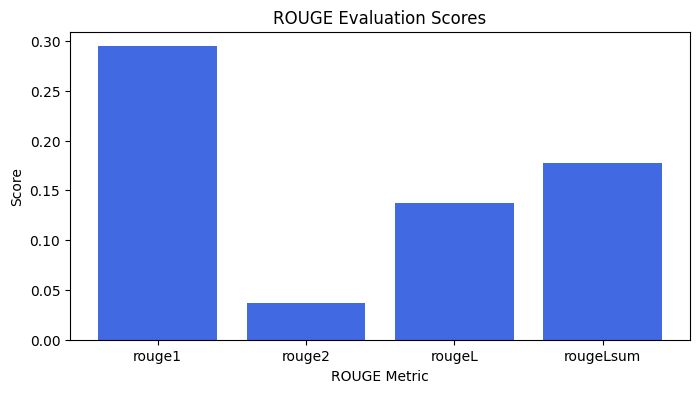

In [19]:
import matplotlib.pyplot as plt

rouge_scores = {
    "rouge1": score["rouge1"],
    "rouge2": score["rouge2"],
    "rougeL": score["rougeL"],
    "rougeLsum": score["rougeLsum"]
}

plt.figure(figsize=(8, 4))
plt.bar(rouge_scores.keys(), rouge_scores.values(), color='royalblue')
plt.title("ROUGE Evaluation Scores")
plt.ylabel("Score")
plt.xlabel("ROUGE Metric")
plt.show()

**Bert Score**

In [16]:
bertscore = evaluate.load("bertscore")
scoreb = bertscore.compute(predictions =test_df.Predicted_Response, references= test_df.Response, lang='en' )


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
sum(scoreb['f1'])/len(scoreb['f1'])

0.8361348756350422